<a href="https://colab.research.google.com/github/Overlord15/Deep-Learning-Lab-IA1/blob/main/Question1_Residual_CNN_From_Scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Question 1: Residual Convolutional Neural Network from Scratch
## Image Classification on CIFAR-10

This notebook implements a Residual CNN architecture from scratch using TensorFlow/Keras.

**Architecture Components:**
- Residual Convolutional Blocks (RCB): Conv -> BN -> ReLU -> Conv -> BN -> ReLU
- Shortcut connections (identity or projection)
- MaxPooling between blocks
- Global Average Pooling before final classification

In [1]:
# Import required libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import numpy as np
import matplotlib.pyplot as plt

print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.19.0


In [2]:
# Load and preprocess CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Normalize pixel values to [0, 1]
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# One-hot encode labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

print(f"Training data shape: {x_train.shape}")
print(f"Training labels shape: {y_train.shape}")
print(f"Test data shape: {x_test.shape}")
print(f"Test labels shape: {y_test.shape}")

# CIFAR-10 class names
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
Training data shape: (50000, 32, 32, 3)
Training labels shape: (50000, 10)
Test data shape: (10000, 32, 32, 3)
Test labels shape: (10000, 10)


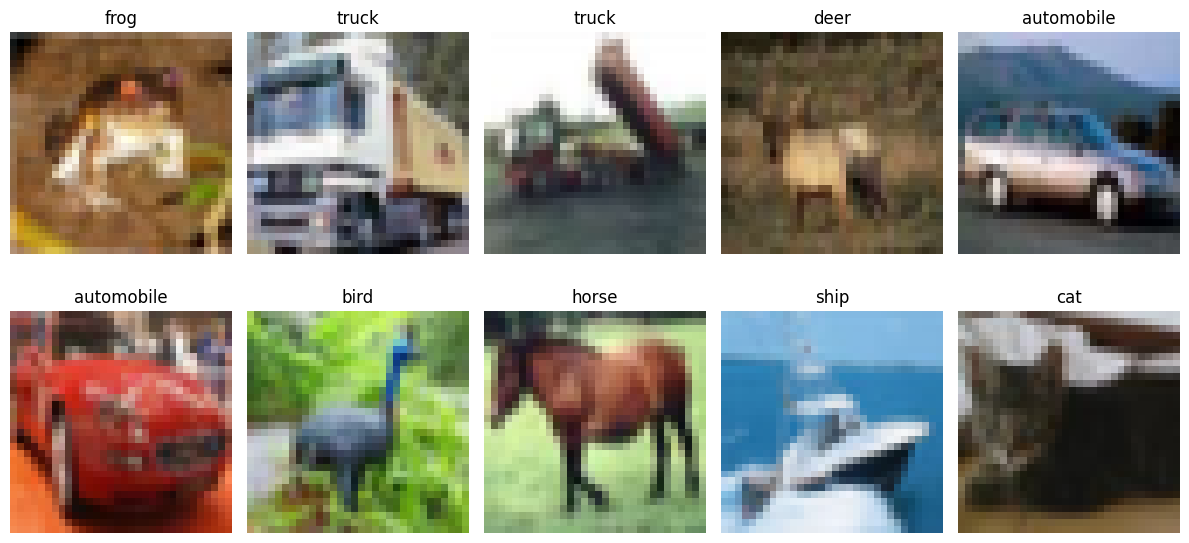

In [3]:
# Visualize some sample images
plt.figure(figsize=(12, 6))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[np.argmax(y_train[i])])
    plt.axis('off')
plt.tight_layout()
plt.show()

In [4]:
# Define Residual Convolutional Block (RCB)
def residual_block(x, filters, kernel_size=3, stride=1, use_projection=False):
    """
    Residual Convolutional Block with shortcut connection

    Structure: Conv -> BN -> ReLU -> Conv -> BN -> ReLU + Shortcut

    Args:
        x: Input tensor
        filters: Number of filters for conv layers
        kernel_size: Size of convolutional kernel (default: 3)
        stride: Stride for first convolution (default: 1)
        use_projection: Whether to use 1x1 conv for shortcut when dimensions change

    Returns:
        Output tensor after residual block
    """
    shortcut = x

    # First Conv -> BN -> ReLU
    x = layers.Conv2D(filters, kernel_size, strides=stride, padding='same',
                      kernel_initializer='he_normal')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    # Second Conv -> BN (no ReLU before addition)
    x = layers.Conv2D(filters, kernel_size, strides=1, padding='same',
                      kernel_initializer='he_normal')(x)
    x = layers.BatchNormalization()(x)

    # Shortcut connection (projection if dimensions don't match)
    if use_projection or stride != 1:
        shortcut = layers.Conv2D(filters, 1, strides=stride, padding='same',
                                 kernel_initializer='he_normal')(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    # Add shortcut and apply ReLU
    x = layers.Add()([x, shortcut])
    x = layers.ReLU()(x)

    return x

In [5]:
# Build Residual CNN Model from Scratch
def build_residual_cnn(input_shape=(32, 32, 3), num_classes=10):
    """
    Build a Residual CNN architecture from scratch

    Architecture:
    - Initial Conv layer
    - RCB1 (64 filters) -> MaxPool
    - RCB2 (128 filters) -> MaxPool
    - RCB3 (256 filters) -> MaxPool
    - Global Average Pooling
    - Dense layers with Dropout
    - Output layer

    Args:
        input_shape: Shape of input images
        num_classes: Number of output classes

    Returns:
        Keras Model
    """
    inputs = layers.Input(shape=input_shape)

    # Initial Convolution
    x = layers.Conv2D(64, 3, strides=1, padding='same',
                      kernel_initializer='he_normal')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    # Residual Block 1 (64 filters) + MaxPool
    x = residual_block(x, 64, use_projection=False)
    x = residual_block(x, 64, use_projection=False)
    x = layers.MaxPooling2D(pool_size=2, strides=2)(x)

    # Residual Block 2 (128 filters) + MaxPool
    x = residual_block(x, 128, use_projection=True)
    x = residual_block(x, 128, use_projection=False)
    x = layers.MaxPooling2D(pool_size=2, strides=2)(x)

    # Residual Block 3 (256 filters) + MaxPool
    x = residual_block(x, 256, use_projection=True)
    x = residual_block(x, 256, use_projection=False)
    x = layers.MaxPooling2D(pool_size=2, strides=2)(x)

    # Global Average Pooling
    x = layers.GlobalAveragePooling2D()(x)

    # Dense layers with Dropout for regularization
    x = layers.Dense(512, kernel_initializer='he_normal')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Dropout(0.5)(x)

    x = layers.Dense(256, kernel_initializer='he_normal')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Dropout(0.4)(x)

    # Output layer
    outputs = layers.Dense(num_classes, activation='softmax',
                          kernel_initializer='glorot_uniform')(x)

    model = models.Model(inputs=inputs, outputs=outputs, name='Residual_CNN')
    return model

In [6]:
# Create the model
model = build_residual_cnn(input_shape=(32, 32, 3), num_classes=10)

# Display model summary
model.summary()

Model: "Residual_CNN"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 32, 32,    │      1,792 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 32, 32,    │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 32, 32,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 32, 32,    │     36,928 │ re_lu[0][0]       │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 32, 32,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 32, 32,    │     36,928 │ re_lu_1[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 32, 32,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │ re_lu[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 32, 32,    │          0 │ add[0][0]         │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 32, 32,    │     36,928 │ re_lu_2[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 32, 32,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │     36,928 │ re_lu_3[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 32, 32,    │          0 │ batch_normalizat

 Total params: 3,050,378 (11.64 MB)

 Trainable params: 3,044,362 (11.61 MB)

 Non-trainable params: 6,016 (23.50 KB)

In [7]:
# Compile the model
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully!")

Model compiled successfully!


In [8]:
# Define callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-7,
    verbose=1
)

callbacks = [early_stopping, reduce_lr]

In [9]:
# Train the model
epochs = 50
batch_size = 64

history = model.fit(
    x_train, y_train,
    batch_size=batch_size,
    epochs=epochs,
    validation_data=(x_test, y_test),
    callbacks=callbacks,
    verbose=1
)

Epoch 1/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 69s 59ms/step - accuracy: 0.5023 - loss: 1.3947 - val_accuracy: 0.5334 - val_loss: 1.4058 - learning_rate: 0.0010
Epoch 2/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 35s 45ms/step - accuracy: 0.7093 - loss: 0.8339 - val_accuracy: 0.6213 - val_loss: 1.2004 - learning_rate: 0.0010
Epoch 3/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 36s 46ms/step - accuracy: 0.7871 - loss: 0.6284 - val_accuracy: 0.6656 - val_loss: 0.9938 - learning_rate: 0.0010
Epoch 4/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 35s 45ms/step - accuracy: 0.8300 - loss: 0.5082 - val_accuracy: 0.7609 - val_loss: 0.6997 - learning_rate: 0.0010
Epoch 5/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 36s 46ms/step - accuracy: 0.8592 - loss: 0.4135 - val_accuracy: 0.6791 - val_loss: 1.0043 - learning_rate: 0.0010
Epoch 6/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 36s 46ms/step - accuracy: 0.8856 - loss: 0.3386 - val_accuracy: 0.8116 - val_loss: 0.5593 - learning_rate: 0.0010
Epoch 7/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 36s 45ms/step - accuracy: 0.9036 - l

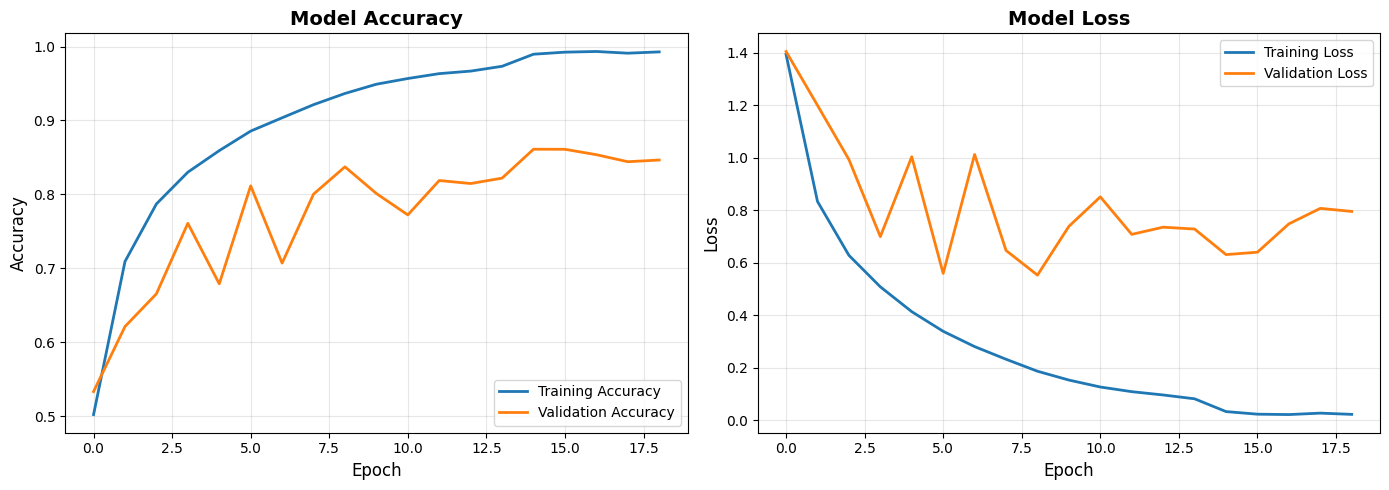

In [10]:
# Plot training history - Accuracy
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
plt.title('Model Accuracy', fontsize=14, fontweight='bold')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)

# Plot training history - Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
plt.title('Model Loss', fontsize=14, fontweight='bold')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [11]:
# Evaluate the model on test set
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=1)

print(f"\n{'='*50}")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"{'='*50}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8373 - loss: 0.5528

Test Loss: 0.5528
Test Accuracy: 0.8373 (83.73%)


In [12]:
# Make predictions on test set
predictions = model.predict(x_test)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = np.argmax(y_test, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step


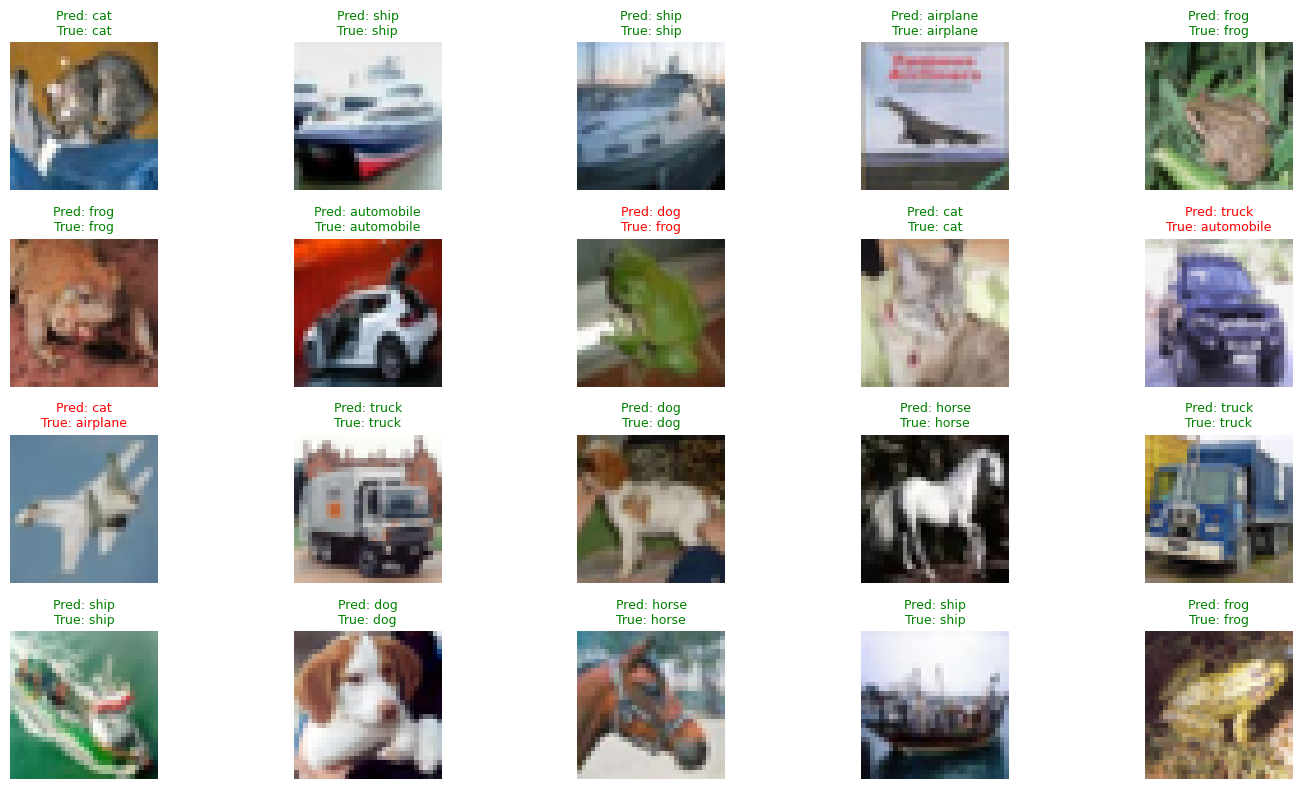

In [13]:
# Visualize some predictions
plt.figure(figsize=(15, 8))
for i in range(20):
    plt.subplot(4, 5, i + 1)
    plt.imshow(x_test[i])
    predicted_label = class_names[predicted_classes[i]]
    true_label = class_names[true_classes[i]]
    color = 'green' if predicted_classes[i] == true_classes[i] else 'red'
    plt.title(f"Pred: {predicted_label}\nTrue: {true_label}",
              color=color, fontsize=9)
    plt.axis('off')
plt.tight_layout()
plt.show()

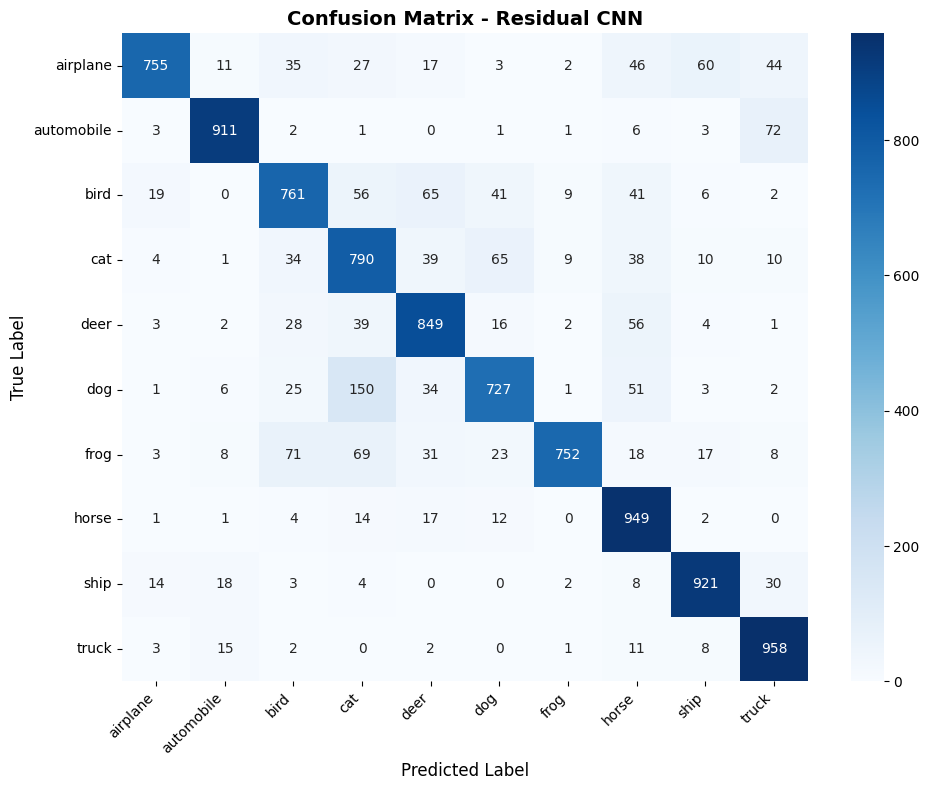


Classification Report:
              precision    recall  f1-score   support

    airplane       0.94      0.76      0.84      1000
  automobile       0.94      0.91      0.92      1000
        bird       0.79      0.76      0.77      1000
         cat       0.69      0.79      0.73      1000
        deer       0.81      0.85      0.83      1000
         dog       0.82      0.73      0.77      1000
        frog       0.97      0.75      0.85      1000
       horse       0.78      0.95      0.85      1000
        ship       0.89      0.92      0.91      1000
       truck       0.85      0.96      0.90      1000

    accuracy                           0.84     10000
   macro avg       0.85      0.84      0.84     10000
weighted avg       0.85      0.84      0.84     10000



In [14]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Residual CNN', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Classification Report
print("\nClassification Report:")
print("="*60)
print(classification_report(true_classes, predicted_classes,
                          target_names=class_names))

## Summary

This notebook demonstrates:
1. **Residual Block Implementation**: Custom residual blocks with Conv->BN->ReLU->Conv->BN->ReLU + shortcut
2. **Shortcut Connections**: Identity shortcuts and projection shortcuts (1x1 conv) when dimensions change
3. **Architecture**: Multiple residual blocks with increasing filter sizes (64->128->256)
4. **MaxPooling**: Applied between residual block groups for spatial downsampling
5. **Training**: Complete training pipeline with callbacks for early stopping and learning rate reduction
6. **Evaluation**: Comprehensive evaluation with accuracy curves, confusion matrix, and classification report

The residual connections help prevent vanishing gradients and enable training of deeper networks.